# Evolução Patrimonial no Setor Elétrico Brasileiro
*Comparativo do Patrimônio Líquido de empresas de Energia entre 2020 e 2025, com dados da CVM*

Autor: Wellington Moreira <br>
Contato: https://www.linkedin.com/in/wellington-moreira-santos/ <br>
E-mail: wsantos08@hotmail.com

---

Neste projeto, eu analiso a evolução do Patrimônio Líquido Consolidado de cinco empresas do setor elétrico brasileiro, Cemig, Copel, CPFL, Taesa e ISA Energia Brasil, ao longo do período de 2020 a 2025. ISA Energia Brasil é o nome atual da antiga ISA CTEEP, que negociava como TRPL4 e passou a se chamar ISA Energia Brasil em novembro de 2024, uma empresa de transmissão distinta da Taesa, embora ambas atuem no mesmo segmento. Utilizo os dados abertos de Demonstrações Financeiras Padronizadas, DFP, disponibilizados pela CVM, Comissão de Valores Mobiliários, com foco no Balanço Patrimonial Passivo Consolidado de cada companhia.

A escolha dessas cinco empresas se justifica pela relevância delas em diferentes elos do setor elétrico brasileiro, geração e distribuição, com Cemig, Copel e CPFL, e transmissão, com Taesa e ISA Energia Brasil. Isso permite observar o comportamento patrimonial de companhias com perfis distintos dentro do mesmo setor ao longo de um período recente. Este projeto retoma a lógica de análise horizontal já explorada em outro trabalho deste repositório, aplicando o cálculo de variação percentual acumulada a partir de um ano base para acompanhar o crescimento, ou a retração, patrimonial de cada empresa.

Para a coleta e o tratamento dos dados, utilizo principalmente as bibliotecas wget, para o download automatizado dos arquivos da CVM, zipfile, para a extração dos dados compactados, e pandas, para a manipulação e consolidação dos dataframes. As visualizações são construídas com matplotlib.

O notebook está organizado nas seguintes seções.

1. Imports e Configurações
2. Coleta e Inspeção dos Dados
3. Limpeza e Tratamento dos Dados
4. Análise Exploratória
5. Visualizações
6. Conclusão e Considerações Finais
7. Referências

## 1. Imports e Configurações

In [4]:
!python.exe -m pip install --upgrade pip

  Using cached pip-26.1.2-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.1.1
    Uninstalling pip-25.1.1:
      Successfully uninstalled pip-25.1.1


In [1]:
!pip install -qU wget

In [11]:
import os
import wget
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import session_info
from zipfile import ZipFile

In [12]:
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

os.makedirs('Dados/zip', exist_ok=True)
os.makedirs('Dados/csv', exist_ok=True)

session_info.show(dependencies=False)

## 2. Coleta e Inspeção dos Dados

### 2.1 Download e extração dos dados da DFP

In [16]:
anos = list(range(2020, 2026))

for ano in anos:
    url = f'https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/DFP/DADOS/dfp_cia_aberta_{ano}.zip'
    try:
        arquivo = wget.download(url, out='Dados/zip')
        print('')
        with ZipFile(arquivo, 'r') as zip_ref: # with :: contexto para arq não ficar em memoria
            zip_ref.extractall('Dados/csv')            
    except Exception as e:         
        print(f'Erro no ano {ano}: {str(e)}\n')

100% [........................................................................] 12637854 / 12637854
100% [........................................................................] 13283026 / 13283026
100% [........................................................................] 13449133 / 13449133
100% [........................................................................] 13563503 / 13563503
100% [........................................................................] 13396203 / 13396203
100% [........................................................................] 12706916 / 12706916


### 2.2 Leitura e consolidação do Balanço Patrimonial Passivo

In [85]:
lista_bpp = []

for ano in anos:
    bpp_ano = pd.read_csv(f'Dados/csv/dfp_cia_aberta_BPP_con_{ano}.csv',
                           sep=';',
                           decimal=',',
                           encoding='ISO-8859-1')
    bpp_ano['ANO_REFERENCIA'] = ano
    lista_bpp.append(bpp_ano)

bpp_consolidado = pd.concat(lista_bpp, ignore_index=True)

### 2.3 Visão geral do dataframe consolidado

> O dataframe consolidado reúne o Balanço Patrimonial Passivo de todas as companhias abertas para os seis anos do período analisado, com a coluna ANO_REFERENCIA permitindo identificar a origem de cada registro.

In [86]:
# visao geral :: primeiros e ultimos registros
bpp_consolidado

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA,ANO_REFERENCIA
0,00.000.000/0001-91,2020-12-31,2,BCO BRASIL S.A.,1023,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,PENÚLTIMO,2019-12-31,2,Passivo Total,1452266807.0000000000,S,2020
1,00.000.000/0001-91,2020-12-31,2,BCO BRASIL S.A.,1023,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2020-12-31,2,Passivo Total,1693794003.0000000000,S,2020
2,00.000.000/0001-91,2020-12-31,2,BCO BRASIL S.A.,1023,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,PENÚLTIMO,2019-12-31,2.01,Passivos Financeiros Avaliados ao Valor Justo ...,961636.0000000000,S,2020
3,00.000.000/0001-91,2020-12-31,2,BCO BRASIL S.A.,1023,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2020-12-31,2.01,Passivos Financeiros Avaliados ao Valor Justo ...,3098315.0000000000,S,2020
4,00.000.000/0001-91,2020-12-31,2,BCO BRASIL S.A.,1023,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,PENÚLTIMO,2019-12-31,2.02,Passivos Financeiros ao Custo Amortizado,1272377717.0000000000,S,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630840,97.837.181/0001-47,2025-12-31,1,DEXCO S.A.,21091,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2025-12-31,2.03.07,Ajustes Acumulados de Conversão,0.0000000000,S,2025
630841,97.837.181/0001-47,2025-12-31,1,DEXCO S.A.,21091,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,PENÚLTIMO,2024-12-31,2.03.08,Outros Resultados Abrangentes,0.0000000000,S,2025
630842,97.837.181/0001-47,2025-12-31,1,DEXCO S.A.,21091,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2025-12-31,2.03.08,Outros Resultados Abrangentes,0.0000000000,S,2025
630843,97.837.181/0001-47,2025-12-31,1,DEXCO S.A.,21091,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,PENÚLTIMO,2024-12-31,2.03.09,Participação dos Acionistas Não Controladores,218195.0000000000,S,2025


In [87]:
# informações gerais
bpp_consolidado.info()

<class 'pandas.DataFrame'>
RangeIndex: 630845 entries, 0 to 630844
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   CNPJ_CIA        630845 non-null  str  
 1   DT_REFER        630845 non-null  str  
 2   VERSAO          630845 non-null  int64
 3   DENOM_CIA       630845 non-null  str  
 4   CD_CVM          630845 non-null  int64
 5   GRUPO_DFP       630845 non-null  str  
 6   MOEDA           630845 non-null  str  
 7   ESCALA_MOEDA    630845 non-null  str  
 8   ORDEM_EXERC     630845 non-null  str  
 9   DT_FIM_EXERC    630845 non-null  str  
 10  CD_CONTA        630845 non-null  str  
 11  DS_CONTA        630845 non-null  str  
 12  VL_CONTA        630845 non-null  str  
 13  ST_CONTA_FIXA   630845 non-null  str  
 14  ANO_REFERENCIA  630845 non-null  int64
dtypes: int64(3), str(12)
memory usage: 180.8 MB


> O dataframe consolidado reúne 630.845 registros em 15 colunas, cobrindo todas as companhias abertas que entregaram Balanço Patrimonial Passivo entre 2020 e 2025.
>
> A maior parte das colunas aparece como texto, incluindo `VL_CONTA`, que deveria ser numérica. Trato conversões a seguir.

## 3. Limpeza e Tratamento dos Dados

 Aqui converto as colunas de data e os valores numéricos para os tipos adequados, e mantenho apenas os registros com `ORDEM_EXERC` igual a `ÚLTIMO`, eliminando os valores do exercício anterior que cada arquivo traz apenas para efeito de comparação.

In [88]:
antes = bpp_consolidado.shape[0]
bpp_consolidado = bpp_consolidado.assign(
    DT_REFER     = pd.to_datetime(bpp_consolidado['DT_REFER']),
    DT_FIM_EXERC = pd.to_datetime(bpp_consolidado['DT_FIM_EXERC']),
    VERSAO       = pd.to_numeric (bpp_consolidado['VERSAO']),
    VL_CONTA     = pd.to_numeric (bpp_consolidado['VL_CONTA']),
)

bpp_consolidado = bpp_consolidado[bpp_consolidado['ORDEM_EXERC'] == 'ÚLTIMO']
depois = bpp_consolidado.shape[0]

print('Antes do tratamento : ', antes)
print('Depois do tratamento: ', depois)

Antes do tratamento :  630845
Depois do tratamento:  315801


> O dataframe reduziu de 630.845 para 315.801 registros, um corte de praticamente metade, decorrente sobretudo do filtro de `ORDEM_EXERC`, já que cada conta contábil aparece duas vezes por registro original, uma para o exercício atual e outra para o anterior.

In [128]:
bpp_consolidado.info()

<class 'pandas.DataFrame'>
Index: 315801 entries, 1 to 630844
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   CNPJ_CIA        315801 non-null  str           
 1   DT_REFER        315801 non-null  datetime64[us]
 2   VERSAO          315801 non-null  int64         
 3   DENOM_CIA       315801 non-null  str           
 4   CD_CVM          315801 non-null  int64         
 5   GRUPO_DFP       315801 non-null  str           
 6   MOEDA           315801 non-null  str           
 7   ESCALA_MOEDA    315801 non-null  str           
 8   ORDEM_EXERC     315801 non-null  str           
 9   DT_FIM_EXERC    315801 non-null  datetime64[us]
 10  CD_CONTA        315801 non-null  str           
 11  DS_CONTA        315801 non-null  str           
 12  VL_CONTA        315801 non-null  float64       
 13  ST_CONTA_FIXA   315801 non-null  str           
 14  ANO_REFERENCIA  315801 non-null  int64         
dtyp

> As colunas de data e o `VL_CONTA` ficam com os tipos corretos para os cálculos das próximas seções.

## 4. Análise Exploratória

### 4.1 Filtragem das empresas de interesse

Antes de isolar o Patrimônio Líquido, localizo corretamente as cinco empresas de interesse dentro da base consolidada. Busco pelo nome na coluna `DENOM_CIA` e depois confirmo qual denominação corresponde à holding de cada grupo, já que a CVM também reporta demonstrações de subsidiárias e segmentos operacionais separadamente.

#### 4.1.1 Busca por nomes das companhias

In [110]:
bpp_consolidado[bpp_consolidado['DENOM_CIA'] \
    .str.contains('TRANSMISSORA ALIANÇA|ISA ENERGIA|CEMIG|COPEL|CPFL', case=False, na=False) ] \
    [['CD_CVM', 'DENOM_CIA']] \
    .drop_duplicates()

,CD_CVM,DENOM_CIA
7365,18660,CPFL ENERGIA S.A.
10699,18376,ISA ENERGIA BRASIL
13081,18953,CPFL GERACAO DE ENERGIA S.A.
14797,24740,COPEL GERAÇÃO E TRANSMISSÃO S.A.
19455,20320,CEMIG GERACAO E TRANSMISSAO S.A.
23925,20257,TRANSMISSORA ALIANÇA DE ENERGIA ELÉTRICA S.A.
27397,20540,CPFL ENERGIAS RENOVÁVEIS S.A.
47597,2453,CIA ENERGETICA DE MINAS GERAIS - CEMIG
86619,14311,CIA PARANAENSE DE ENERGIA - COPEL
97331,3204,CPFL TRANSMISSÃO S.A.


#### 4.1.2 Seleção de empresas

Seleciono aqui as cinco holdings que representam os diferentes elos do setor, geração e distribuição, com Cemig, Copel e CPFL, e transmissão, com Taesa e ISA Energia Brasil.

In [111]:
# filtro das empresas de geração, transmissão, distribuição e comercialização de economia mista 
empresas = bpp_consolidado[bpp_consolidado['DENOM_CIA'].isin([
    'TRANSMISSORA ALIANÇA DE ENERGIA ELÉTRICA S.A.',
    'CPFL ENERGIA S.A.',
    'CIA ENERGETICA DE MINAS GERAIS - CEMIG', 
    'CIA PARANAENSE DE ENERGIA - COPEL',
    'ISA ENERGIA BRASIL'
])]
empresas

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA,ANO_REFERENCIA
7365,02.429.144/0001-93,2020-12-31,2,CPFL ENERGIA S.A.,18660,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2020-12-31,2,Passivo Total,49106884.0,S,2020
7367,02.429.144/0001-93,2020-12-31,2,CPFL ENERGIA S.A.,18660,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2020-12-31,2.01,Passivo Circulante,14405951.0,S,2020
7369,02.429.144/0001-93,2020-12-31,2,CPFL ENERGIA S.A.,18660,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2020-12-31,2.01.01,Obrigações Sociais e Trabalhistas,133429.0,S,2020
7371,02.429.144/0001-93,2020-12-31,2,CPFL ENERGIA S.A.,18660,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2020-12-31,2.01.01.01,Obrigações Sociais,30654.0,S,2020
7373,02.429.144/0001-93,2020-12-31,2,CPFL ENERGIA S.A.,18660,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2020-12-31,2.01.01.02,Obrigações Trabalhistas,102775.0,S,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618824,76.483.817/0001-20,2025-12-31,1,CIA PARANAENSE DE ENERGIA - COPEL,14311,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2025-12-31,2.03.05,Lucros/Prejuízos Acumulados,0.0,S,2025
618826,76.483.817/0001-20,2025-12-31,1,CIA PARANAENSE DE ENERGIA - COPEL,14311,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2025-12-31,2.03.06,Ajustes de Avaliação Patrimonial,287992.0,S,2025
618828,76.483.817/0001-20,2025-12-31,1,CIA PARANAENSE DE ENERGIA - COPEL,14311,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2025-12-31,2.03.07,Ajustes Acumulados de Conversão,0.0,S,2025
618830,76.483.817/0001-20,2025-12-31,1,CIA PARANAENSE DE ENERGIA - COPEL,14311,DF Consolidado - Balanço Patrimonial Passivo,REAL,MIL,ÚLTIMO,2025-12-31,2.03.08,Outros Resultados Abrangentes,0.0,S,2025


> O filtro resulta em 3.808 registros, um recorte já bem menor e específico das cinco companhias analisadas, ainda contendo todas as contas do Balanço Patrimonial Passivo para os seis anos.

#### 4.1.3 Confirmações sobre empresas

Aqui confirmo que a seleção trouxe exatamente as cinco empresas esperadas, sem duplicidade, e que o período de seis anos está completo para o grupo.

In [113]:
# empresas do dataset
empresas.DENOM_CIA.unique()

<ArrowStringArray>
[                            'CPFL ENERGIA S.A.',
                            'ISA ENERGIA BRASIL',
 'TRANSMISSORA ALIANÇA DE ENERGIA ELÉTRICA S.A.',
        'CIA ENERGETICA DE MINAS GERAIS - CEMIG',
             'CIA PARANAENSE DE ENERGIA - COPEL']
Length: 5, dtype: str

In [116]:
# cod cvm
empresas.CD_CVM.unique()

array([18660, 18376, 20257,  2453, 14311])

In [114]:
# anos
empresas.ANO_REFERENCIA.unique()

array([2020, 2021, 2022, 2023, 2024, 2025])

### 4.2 Contas do Passivo

Verifico quantas contas distintas cada empresa reporta, já que o nível de detalhamento do Balanço Patrimonial Passivo varia de uma companhia para outra.

In [115]:
empresas[['DENOM_CIA', 'CD_CONTA', 'DS_CONTA']].drop_duplicates()

,DENOM_CIA,CD_CONTA,DS_CONTA
7365,CPFL ENERGIA S.A.,2,Passivo Total
7367,CPFL ENERGIA S.A.,2.01,Passivo Circulante
7369,CPFL ENERGIA S.A.,2.01.01,Obrigações Sociais e Trabalhistas
7371,CPFL ENERGIA S.A.,2.01.01.01,Obrigações Sociais
7373,CPFL ENERGIA S.A.,2.01.01.02,Obrigações Trabalhistas
...,...,...,...
517228,CIA PARANAENSE DE ENERGIA - COPEL,2.03.02.07,Incentivos de longo prazo
576560,CIA ENERGETICA DE MINAS GERAIS - CEMIG,2.01.05.02.17,Indenização compensatória
576644,CIA ENERGETICA DE MINAS GERAIS - CEMIG,2.02.02.02.14,Indenização compensatória
618764,CIA PARANAENSE DE ENERGIA - COPEL,2.02.04.02.05,Passivo Contingente de Combinação de Negócios


In [118]:
empresas.groupby('DENOM_CIA')[['CD_CONTA', 'DS_CONTA']].count()

,CD_CONTA,DS_CONTA
DENOM_CIA,,
CIA ENERGETICA DE MINAS GERAIS - CEMIG,850,850
CIA PARANAENSE DE ENERGIA - COPEL,730,730
CPFL ENERGIA S.A.,756,756
ISA ENERGIA BRASIL,786,786
TRANSMISSORA ALIANÇA DE ENERGIA ELÉTRICA S.A.,686,686


> São 656 combinações distintas de conta e descrição entre as cinco empresas, com uma variação relevante no nível de detalhe, a Cemig reporta 850 contas diferentes ao longo do período, contra 686 da Taesa. Todavia, essa diferença não afeta a análise, já que utilizo apenas a conta de Patrimônio Líquido Consolidado, presente em todas as companhias.

### 4.3 Isolando a conta de patrimônio líquido consolidado

In [119]:
empresas[ empresas['DS_CONTA'] == 'Patrimônio Líquido Consolidado' ][['ANO_REFERENCIA', 'DENOM_CIA', 'CD_CONTA', 'DS_CONTA', 'VL_CONTA']]

,ANO_REFERENCIA,DENOM_CIA,CD_CONTA,DS_CONTA,VL_CONTA
7555,2020,CPFL ENERGIA S.A.,2.03,Patrimônio Líquido Consolidado,14235778.0
10895,2020,ISA ENERGIA BRASIL,2.03,Patrimônio Líquido Consolidado,14125442.0
24097,2020,TRANSMISSORA ALIANÇA DE ENERGIA ELÉTRICA S.A.,2.03,Patrimônio Líquido Consolidado,6025904.0
47815,2020,CIA ENERGETICA DE MINAS GERAIS - CEMIG,2.03,Patrimônio Líquido Consolidado,17477348.0
86807,2020,CIA PARANAENSE DE ENERGIA - COPEL,2.03,Patrimônio Líquido Consolidado,20250518.0
107713,2021,CPFL ENERGIA S.A.,2.03,Patrimônio Líquido Consolidado,16805878.0
111159,2021,ISA ENERGIA BRASIL,2.03,Patrimônio Líquido Consolidado,14792735.0
123407,2021,TRANSMISSORA ALIANÇA DE ENERGIA ELÉTRICA S.A.,2.03,Patrimônio Líquido Consolidado,6684756.0
148101,2021,CIA ENERGETICA DE MINAS GERAIS - CEMIG,2.03,Patrimônio Líquido Consolidado,19461765.0
190762,2021,CIA PARANAENSE DE ENERGIA - COPEL,2.03,Patrimônio Líquido Consolidado,22175235.0


In [130]:
pl = empresas[ empresas['DS_CONTA'] == 'Patrimônio Líquido Consolidado' ][['ANO_REFERENCIA', 'DENOM_CIA','VL_CONTA']]

In [135]:
pl.shape

(30, 3)

> O filtro resulta em exatamente 30 registros, cinco empresas ao longo de seis anos, confirmando que a conta de Patrimônio Líquido Consolidado está disponível de forma completa para todo o grupo e período analisados.

### 4.4 Painel empresas x anos

Reorganizo os 30 registros em um painel, com as empresas como índice e os anos como colunas, o que facilita tanto a leitura da evolução quanto o cálculo da variação percentual na etapa seguinte.

In [121]:
pl.pivot(index='DENOM_CIA', columns='ANO_REFERENCIA', values='VL_CONTA')

ANO_REFERENCIA,2020,2021,2022,2023,2024,2025
DENOM_CIA,,,,,,
CIA ENERGETICA DE MINAS GERAIS - CEMIG,17477348.0,19461765.0,21783266.0,24655193.0,27383079.0,28581703.0
CIA PARANAENSE DE ENERGIA - COPEL,20250518.0,22175235.0,21131225.0,24191667.0,25636935.0,23091978.0
CPFL ENERGIA S.A.,14235778.0,16805878.0,17539944.0,19998753.0,21795029.0,23504509.0
ISA ENERGIA BRASIL,14125442.0,14792735.0,16536481.0,17791712.0,20071282.0,21437011.0
TRANSMISSORA ALIANÇA DE ENERGIA ELÉTRICA S.A.,6025904.0,6684756.0,6570476.0,6679310.0,6939504.0,7608982.0


In [123]:
painel_pl = pl.pivot(index='DENOM_CIA', columns='ANO_REFERENCIA', values='VL_CONTA')

> A Cemig termina 2025 com o maior Patrimônio Líquido Consolidado do grupo, R\\$ 28,58 bilhões, seguida por CPFL e Copel, com R\\$ 23,50 bilhões e R\\$ 23,09 bilhões. 
> 
> A Taesa aparece com a menor escala patrimonial do grupo, R\\$ 7,61 bilhões, o que é esperado, já que opera um segmento de transmissão mais restrito que as demais.

### 4.5 Cálculo da variação percentual acumulada

Calculo a variação percentual acumulada de cada empresa em relação a 2020, o que permite comparar o ritmo de crescimento patrimonial das cinco empresas de forma independente da escala absoluta de cada uma.

In [124]:
painel_pl.apply(lambda linha: ((linha / linha[2020]) - 1) * 100, axis=1)

ANO_REFERENCIA,2020,2021,2022,2023,2024,2025
DENOM_CIA,,,,,,
CIA ENERGETICA DE MINAS GERAIS - CEMIG,0.0,11.354223,24.637136,41.069417,56.677541,63.535698
CIA PARANAENSE DE ENERGIA - COPEL,0.0,9.504532,4.349059,19.461966,26.598910,14.031542
CPFL ENERGIA S.A.,0.0,18.053808,23.210295,40.482333,53.100371,65.108707
ISA ENERGIA BRASIL,0.0,4.724050,17.068769,25.955082,42.093125,51.761701
TRANSMISSORA ALIANÇA DE ENERGIA ELÉTRICA S.A.,0.0,10.933662,9.037183,10.843286,15.161211,26.271212


In [125]:
painel_variacao = painel_pl.apply(lambda linha: ((linha / linha[ano_base]) - 1) * 100, axis=1)

> A CPFL Energia lidera a variação acumulada até 2025, com crescimento de 65,1%, seguida de perto pela Cemig, com 63,5%.
>
> A ISA Energia Brasil acumula 51,8% no período.
>
> Taesa e Copel ficam bem abaixo do grupo, com 26,3% e 14,0% respectivamente.
>
> Copel sendo a única com trajetória não linear, registrando queda do Patrimônio Líquido tanto em 2022 quanto em 2025 frente ao ano anterior.

## 5. Visualizações

### 5.1 Evolução do Patrimônio Líquido por empresa

Apresento a evolução do Patrimônio Líquido Consolidado das quatro empresas ao longo do período, em valores absolutos, para observar a trajetória de cada uma lado a lado.

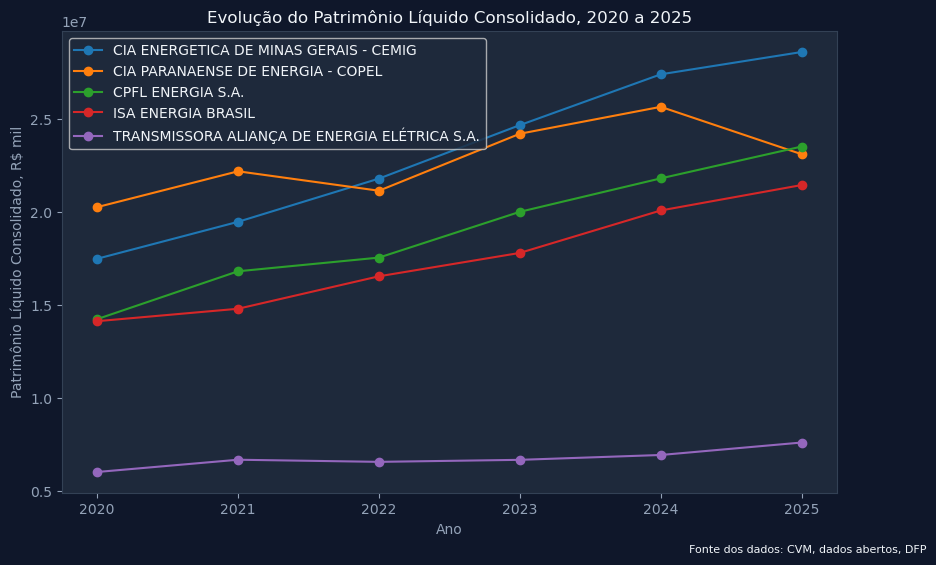

In [136]:
fig, ax = plt.subplots(figsize=(10, 6))

for empresa in painel_pl.index:
    ax.plot(painel_pl.columns, painel_pl.loc[empresa], marker='o', label=empresa)

ax.set_title('Evolução do Patrimônio Líquido Consolidado, 2020 a 2025')
ax.set_xlabel('Ano')
ax.set_ylabel('Patrimônio Líquido Consolidado, R$ mil')
ax.legend()

fig.text(0.99, 0.01, 'Fonte dos dados: CVM, dados abertos, DFP', ha='right', fontsize=8)
plt.show()

> O gráfico confirma a leitura numérica da seção anterior. Cemig, CPFL e ISA Energia Brasil crescem de forma consistente ano a ano. Taesa mantém uma trajetória mais estável e em patamar bem inferior às demais, coerente com sua atuação restrita à transmissão. A Copel se destaca por ser a única linha com dois recuos no período, em 2022 e novamente em 2025, mesmo tendo iniciado 2020 como a maior das cinco empresas em Patrimônio Líquido.

### 5.2 Variação percentual acumulada por empresa

Apresento a variação percentual acumulada de cada empresa até o último ano do período, 2025, o que evidencia o ritmo de crescimento patrimonial de forma comparável entre as quatro companhias.

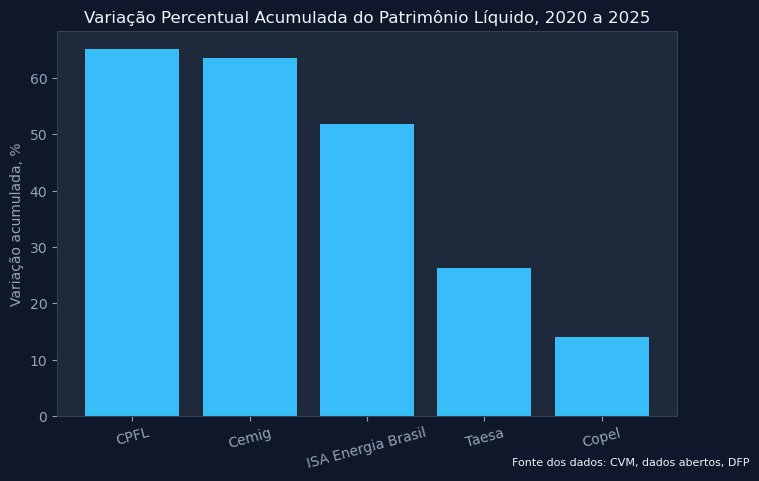

In [137]:
apelidos = {
    'CIA ENERGETICA DE MINAS GERAIS - CEMIG': 'Cemig',
    'CIA PARANAENSE DE ENERGIA - COPEL': 'Copel',
    'CPFL ENERGIA S.A.': 'CPFL',
    'ISA ENERGIA BRASIL': 'ISA Energia Brasil',
    'TRANSMISSORA ALIANÇA DE ENERGIA ELÉTRICA S.A.': 'Taesa',
}

variacao_final = painel_variacao[2025].sort_values(ascending=False)
rotulos = [apelidos[nome] for nome in variacao_final.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(rotulos, variacao_final.values, color='#38bdf8')

ax.set_title('Variação Percentual Acumulada do Patrimônio Líquido, 2020 a 2025')
ax.set_ylabel('Variação acumulada, %')
ax.tick_params(axis='x', rotation=15)

fig.text(0.99, 0.01, 'Fonte dos dados: CVM, dados abertos, DFP', ha='right', fontsize=8)
plt.show()

> O ranking de variação percentual acumulada inverte parcialmente a leitura do gráfico anterior. A Copel, que começou o período com o maior Patrimônio Líquido absoluto, termina com a menor variação acumulada do grupo, evidenciando um crescimento patrimonial mais lento que o das concorrentes apesar da escala inicial.

## 6. Conclusão e Considerações Finais

### 6.1 Síntese do Projeto

Neste projeto, coletei os dados de Balanço Patrimonial Passivo Consolidado de Cemig, Copel, CPFL, Taesa e ISA Energia Brasil entre 2020 e 2025 a partir dos arquivos de DFP da CVM, tratei os tipos de dado, consolidei o histórico em um único painel empresas por anos e calculei a variação percentual acumulada do Patrimônio Líquido de cada empresa a partir de 2020 como ano base.

| Métrica | Valor |
|---|---|
| Período analisado | 2020 a 2025 |
| Empresas comparadas | Cemig, Copel, CPFL, Taesa e ISA Energia Brasil |
| Maior variação acumulada até 2025 | CPFL Energia, 65,1% |
| Menor variação acumulada até 2025 | Copel, 14,0% |

### 6.2 Achados relevantes

A Copel é a única das cinco empresas com trajetória não monótona de Patrimônio Líquido no período, registrando queda tanto em 2022 quanto em 2025. A companhia passou por um processo de privatização concluído em setembro de 2023, o que pode ter reorganizado sua estrutura patrimonial, embora a queda mais recente, em 2025, não coincida diretamente com essa data e essa hipótese não tenha sido aprofundada neste projeto. Chama atenção também que a Taesa registra uma queda pontual em 2022, mesmo ano em que a Copel também recua, o que sugere um efeito possivelmente ligado ao segmento de transmissão ou a fatores macroeconômicos daquele ano, e não apenas a decisões específicas de cada empresa.

### 6.3 Limitações e Considerações

Este projeto considera apenas a conta de Patrimônio Líquido Consolidado, sem incorporar outras contas do Balanço Patrimonial, como Ativo Total ou Passivo Circulante, que poderiam qualificar melhor a leitura de solidez financeira de cada empresa. Os valores utilizados também não foram ajustados pela inflação do período, o que significa que parte do crescimento nominal observado pode refletir apenas a variação de preços na economia. A amostra reúne cinco empresas do setor elétrico com perfis distintos, geração, distribuição e transmissão, o que não permite generalizações para o setor como um todo, nem comparação direta entre empresas de segmentos diferentes. Este projeto tem finalidade educacional e de composição de portfólio.

---


## 7. Referências

* Videoaula [Coletando e Analisando Dados do Balanço Patrimonial em Python](https://youtu.be/YnsQ6fo10sM?si=SbNQaNvdJ97Dmibo), Análise Macro, Luiz Henrique Barbosa Filho.
* [Portal de Dados Abertos da CVM, conjunto DFP](https://dados.cvm.gov.br/dataset/cia_aberta-doc-dfp).
* Documentação [pandas](https://pandas.pydata.org/docs/).
* Documentação [matplotlib](https://matplotlib.org/stable/).

---

> Material desenvolvido para estudos e composição de portfólio a partir da videoaula
> [Coletando e Analisando Dados do Balanço Patrimonial em Python](https://youtu.be/YnsQ6fo10sM?si=SbNQaNvdJ97Dmibo),
> de Análise Macro, para o repositório
> [financas-quantitativas](https://github.com/esscova/financas-quantitativas);
> com auxílio do Claude Anthropic para revisões e estruturação.